# quant-demo — end-to-end pipeline

**Orchestration only.** Every number and chart below is produced by the project's
modules (`data/`, `features/`, `model/`, `backtest/`, `monitoring/`) — this notebook
just wires the stages together and displays the artifacts. All logic lives in the
modules; nothing is re-implemented here.

Each stage is **build-or-load with an immutable cache**, so a cold run builds the
caches once and every later run is near-instant. Randomness is seeded
(`config.SEED`) for bit-reproducibility.

1. `load_prices` · 2. `build_features` · 3. `run_walk_forward` ·
4. `daily_ic / icir` · 5. `build_weights / backtest` · 6. drift report

Presentation-ready charts are written to **`reports/`** as PNG/HTML for slides.

## TL;DR — what this is and how it does

*(Data refreshed through **Jun 2026**; numbers below are out-of-sample over Sep 2016 – May 2026.)*

**1 · What is the training set & evaluation set? What securities, what period?**
Daily **adjusted prices of the TWSE top-50** — the largest companies on the Taiwan
Stock Exchange by market cap (`.TW` tickers; 49 have full history). Raw prices span
**2014 → today (Jun 2026)**; features begin **Jan 2015** (after the 1-year warmup).
Train/eval are split by **purged + embargoed walk-forward**, not a single cut:
- **Training set:** the feature panel **Jan 2015 → May 2026**, minus the purge+embargo
  halo around each test fold (so no overlapping-label leakage).
- **Evaluation set (out-of-sample test):** **Sep 2016 → May 2026** — every (date,
  ticker) predicted exactly once by a model that never saw it. All reported metrics
  (IC, Sharpe, drift) are computed on **this** out-of-sample period only.

*Known caveat: it's today's top-50 list → survivorship bias.*

**2 · Which features does LightGBM consider important?**
No single feature dominates (healthy — no leakage artifact). Top by gain importance:
`beta_63` (10.7%), `dist_sma200` (9.3%), `ret_skew_63` (8.6%), `amihud_21` (8.1%),
`dollar_vol_21` (7.6%), `mom_6_1` (7.5%), `vol_63` (7.5%), `mom_12_1` (6.6%).
→ a balanced mix of **beta, trend, return-shape, liquidity, momentum, volatility**.

**3 · Trading strategy, benchmark, and how it compares?**
- **Strategy:** cross-sectional, **dollar-neutral, sector-neutral, equal-weight
  quintile long-short** — long the top 10 / short the bottom 10 by predicted rank,
  rebalanced every 5 days. A realistic, shortable **long-only top-quintile** variant
  is also run.
- **Costs (real Taiwan stack):** broker fee **0.1425% per side** (NT$20-per-trade
  minimum) + **0.30% securities transaction tax on sells**, on an assumed **NT$100M**
  account. (At NT$100M the NT$20 minimum never binds; it would bite a retail-size book.)
- **Benchmark:** **0050.TW** — the cap-weighted top-50 ETF (≈ buy-and-hold the index),
  over the same Sep 2016 – May 2026 window.
- **Result (net of costs, out-of-sample):**

  | strategy | Sharpe (net) | ann. return |
  | --- | --- | --- |
  | **0050.TW cap-weighted buy-and-hold** *(benchmark)* | **+1.22** | +24.2% |
  | Long-only top-quintile *(model)* | +1.01 | +22.3% |
  | Dollar-neutral long-short *(model)* | −0.67 | −5.2% |

  **The model does not beat the 0050 benchmark after costs** — the long-only variant is
  competitive (Sharpe 1.01 vs 1.22) but still behind, and the dollar-neutral long-short's
  thin gross edge (IC ≈ 0.043) is eaten by ~10%/yr turnover cost. The fix is a longer
  hold / signal smoothing, not a fancier model. **The deliverable is a rigorous, honest
  research loop** (purged validation, IC-first evaluation, real TW costs, drift
  monitoring) — not a deployable edge. *(The benchmark is itself flattered by
  survivorship bias.)*

In [23]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

import config
from data import ingest
from features import alpha
from model import train
from backtest import metrics, portfolio, engine
from monitoring import drift
import run_pipeline  # reuse its seed helper — single source of truth
from IPython.display import Image, IFrame, display

run_pipeline._seed_everything(config.SEED)  # PYTHONHASHSEED + random + numpy
config.REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"seed={config.SEED} | universe={config.UNIVERSE} | reports -> {config.REPORTS_DIR}")

seed=42 | universe=TWSE_TOP50 | reports -> /Users/wanchuan/quant-demo/reports


## 1 · Data ingestion — `ingest.load_prices`

Adjusted daily OHLCV for the TWSE top-50, plus the TAIEX index proxy. Cached to
parquet and treated as immutable. The candlestick is a quick eyeball sanity check
on the headline name (TSMC, `2330.TW`).

In [24]:
prices = ingest.load_prices()
_index = ingest.load_index()
print(f"{len(prices):,} rows | {prices['ticker'].nunique()} tickers | "
      f"{prices['date'].min().date()} → {prices['date'].max().date()}")
prices.head()

148,176 rows | 49 tickers | 2014-01-02 → 2026-06-05


,date,ticker,open,high,low,close,volume
0,2014-01-02,1101.TW,19.488242,19.530653,19.191360,19.254976,11097643.0
1,2014-01-03,1101.TW,19.127742,19.127742,18.873272,18.894478,13527080.0
2,2014-01-06,1101.TW,19.064123,19.064123,18.491564,18.491564,15866789.0
3,2014-01-07,1101.TW,18.576386,18.746035,18.555180,18.724827,15749871.0
4,2014-01-08,1101.TW,18.746037,18.852065,18.512771,18.618801,20160107.0


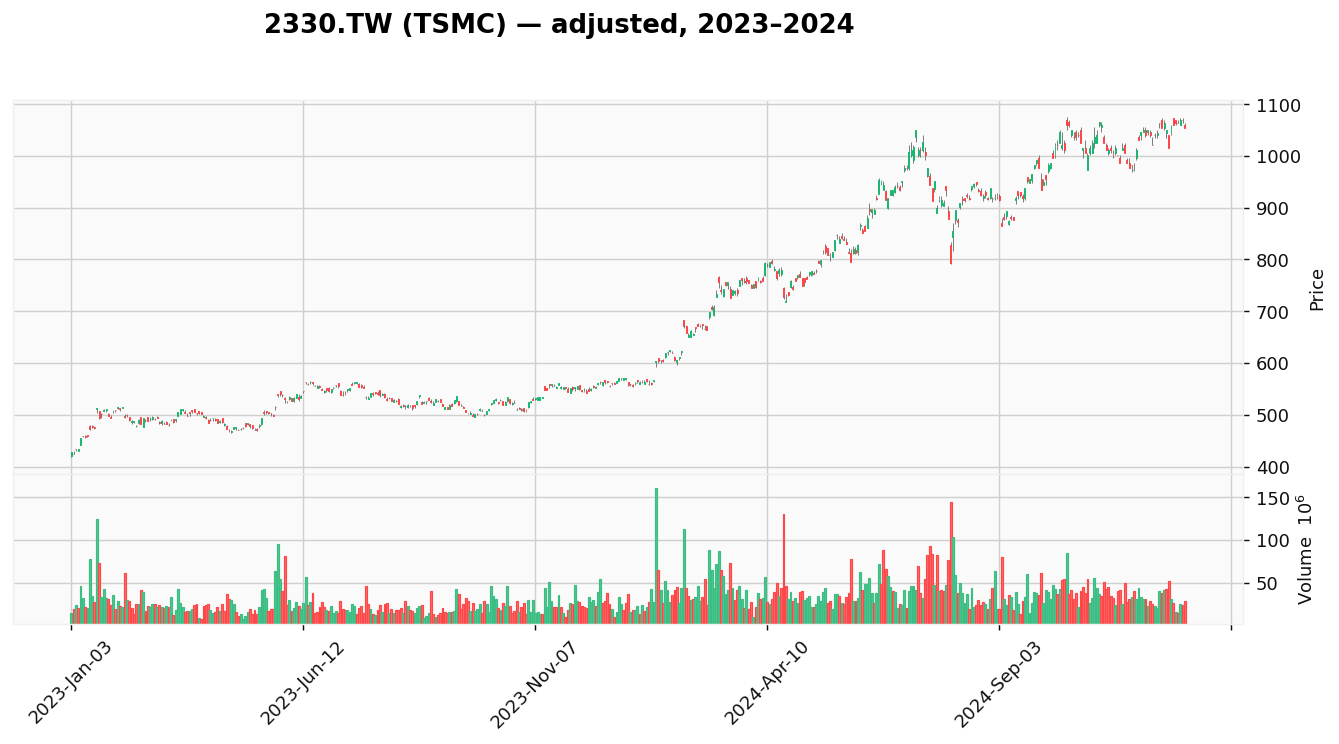

In [25]:
import mplfinance as mpf

tsmc = (prices[prices["ticker"] == "2330.TW"]
        .set_index("date")[["open", "high", "low", "close", "volume"]]
        .loc["2023":"2024"])
price_png = config.REPORTS_DIR / "price_overview_2330.png"
mpf.plot(tsmc, type="candle", volume=True, style="yahoo", figratio=(16, 7),
         title="2330.TW (TSMC) — adjusted, 2023–2024",
         savefig=dict(fname=price_png, dpi=130, bbox_inches="tight"))
display(Image(str(price_png)))

## 2 · Feature engineering — `alpha.load_features`

~18 point-in-time features (momentum, reversal, realized vol, liquidity, trend,
beta), each **cross-sectionally z-scored within every date** so the model trades
on "how a stock looks vs its peers today", not absolute levels.

In [26]:
feats = alpha.load_features()
feature_cols = alpha.feature_columns(feats)
print(f"{len(feats):,} rows | {len(feature_cols)} features (z-scored daily)")
feats[["date", "ticker", "sector"] + feature_cols[:5]].head()

126,324 rows | 18 features (z-scored daily)


,date,ticker,sector,mom_12_1,mom_6_1,rev_5,rev_21,vol_21
0,2015-01-09,1101.TW,Materials,-0.484627,0.151066,-0.955075,-1.438347,-0.559180
1,2015-01-09,1216.TW,ConsumerStaples,-0.674290,-0.513186,-0.047870,-0.128448,-0.081308
2,2015-01-09,1301.TW,Materials,-1.048724,-0.910367,-0.046157,0.210885,0.854778
3,2015-01-09,1303.TW,Materials,-0.775896,-1.018994,-0.438597,-0.288446,0.909742
4,2015-01-09,1326.TW,Materials,-1.274796,-0.689473,-0.924973,-0.758196,0.599874


## 3 · Purged walk-forward model — `train.load_predictions`

LightGBM trained across **purged + embargoed** walk-forward folds (overlapping
10-day labels can't leak across the train/test boundary). Every (date, ticker) is
predicted exactly once, out-of-sample, by a model that never saw its label window.

In [27]:
preds = train.load_predictions()
print(f"{len(preds):,} OOS predictions | {preds['date'].nunique()} dates | "
      f"{preds['date'].min().date()} → {preds['date'].max().date()}")
preds.head()

112,263 OOS predictions | 2292 dates | 2016-09-07 → 2026-05-22


,date,ticker,pred,fwd_ret,fwd_rank,sector
0,2016-09-07,1101.TW,0.023432,-0.038770,-0.755102,Materials
1,2016-09-07,1216.TW,0.000511,0.001695,0.306122,ConsumerStaples
2,2016-09-07,1301.TW,0.030847,-0.018750,-0.306122,Materials
3,2016-09-07,1303.TW,0.046740,-0.006421,0.102041,Materials
4,2016-09-07,1326.TW,0.059927,-0.003513,0.224490,Materials


## 4 · Signal quality — `metrics.daily_ic` / `icir`

Lead with IC, not PnL: with 50 names the portfolio is high-variance, but the IC
aggregates every name every day. Note the **overlap-adjusted ICIR** — daily ICs
share 9/10 of their label window, so the naive √252 figure is inflated.

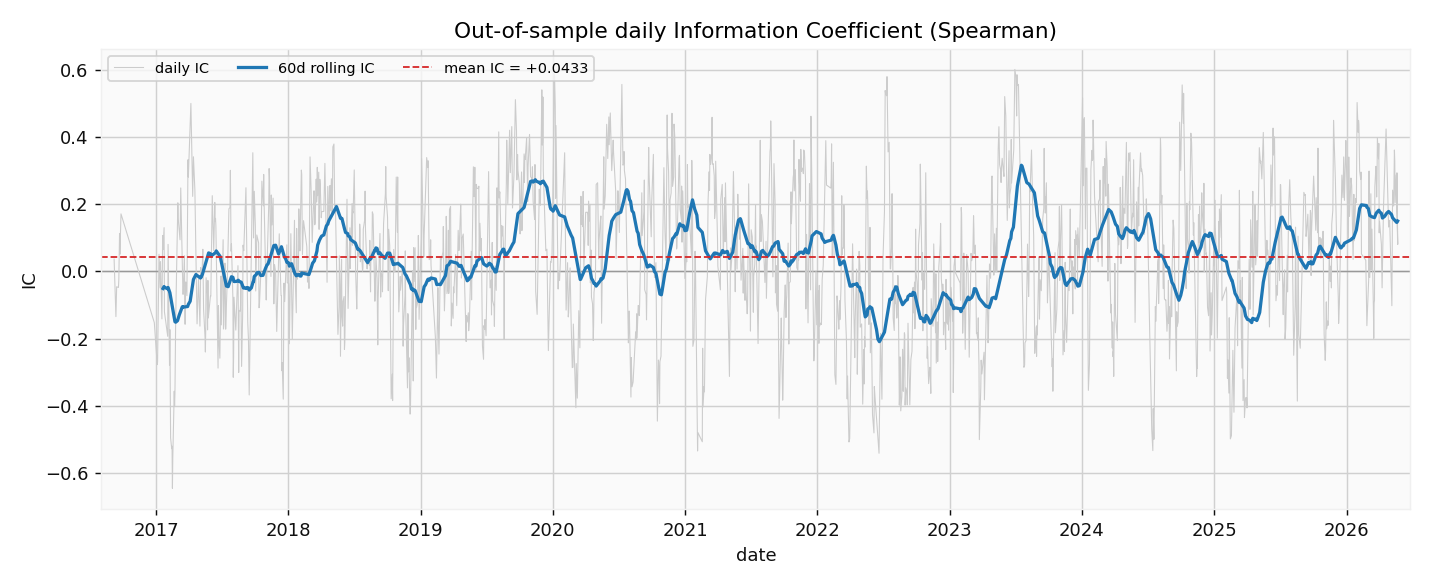

,value
n_days,2292.000000
mean_ic,0.043324
ic_std,0.212045
icir_ann,1.025655
icir_naive,3.243405
ic_autocorr,0.849273
ic_tstat,9.781561
hit_rate,0.584206


In [28]:
ic = metrics.daily_ic(preds)
ic_stats = metrics.summarize_ic(ic)
display(Image(str(metrics.plot_rolling_ic(ic))))
pd.Series(ic_stats).to_frame("value")

## 5–6 · Portfolio + cost-aware backtest — `portfolio.build_weights` / `engine.backtest`

Dollar-neutral, equal-weight quintile long-short (sector-neutralized), rebalanced
every 5 days through our own vectorized engine. Costs are the **real Taiwan stack**:
0.1425% broker fee per side (NT$20-per-trade minimum) + 0.30% sell-side transaction
tax, scaled by an NT$100M account. The **gross-vs-net gap is the honesty proof**; the
long-only top-quintile is the realistic, shortable deployment.

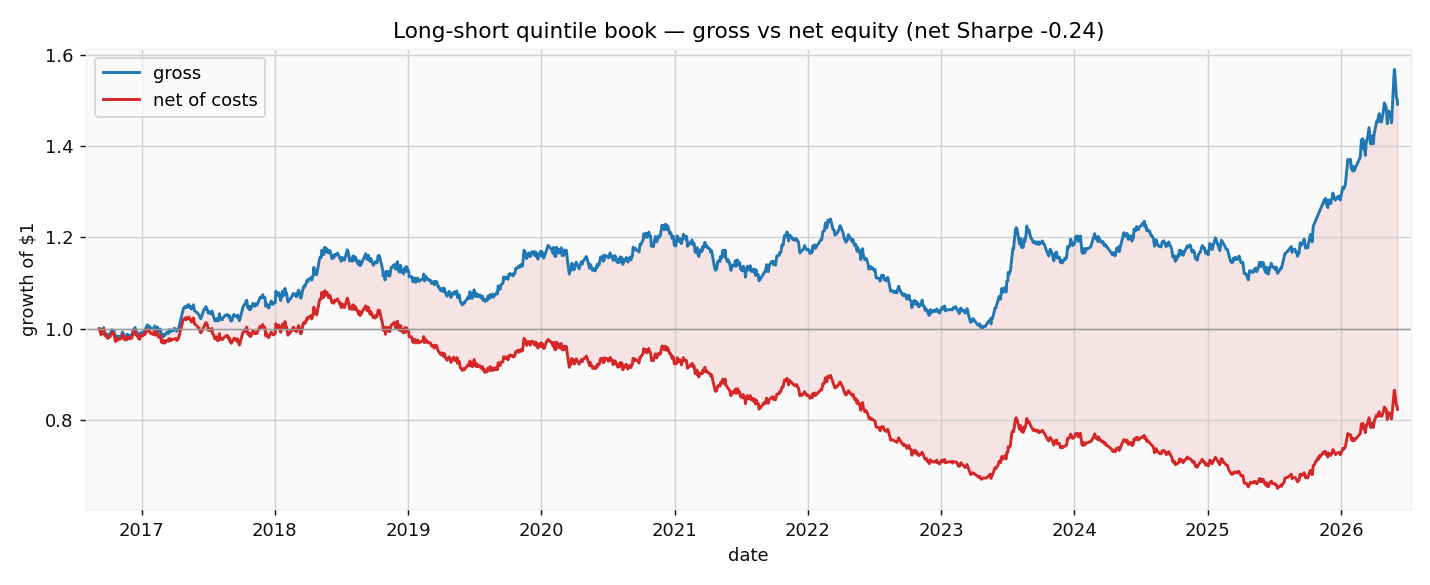

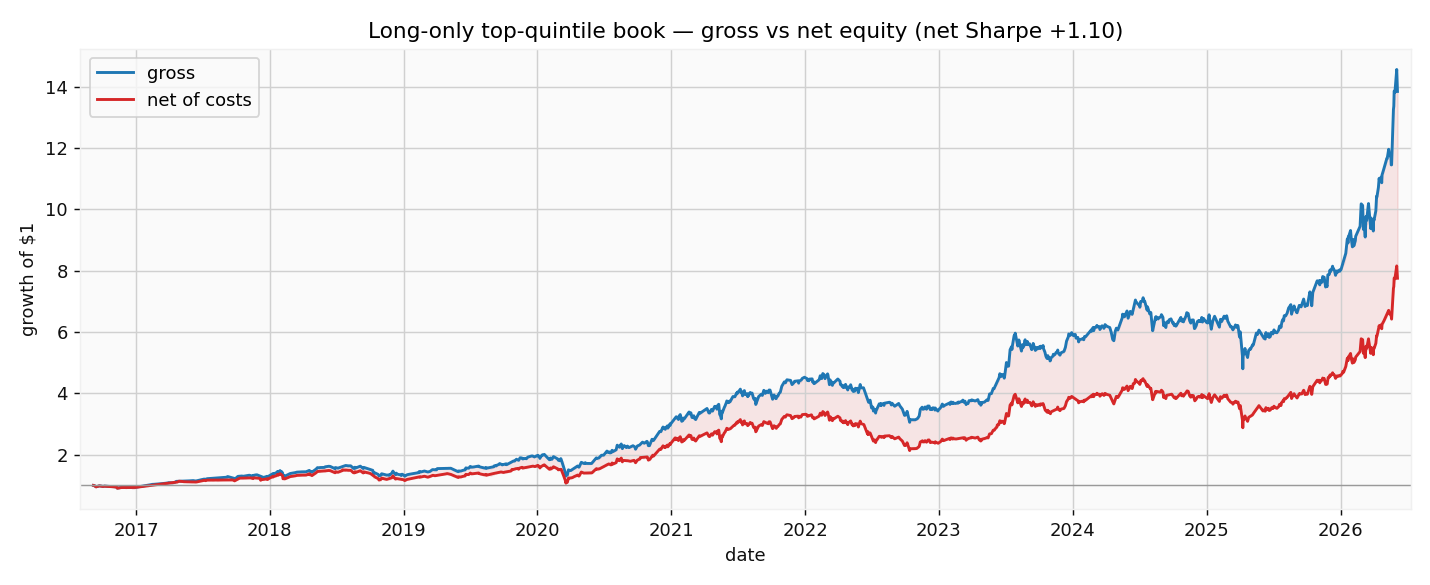

In [29]:
rets = engine.daily_returns(prices)
w_ls = portfolio.build_weights(preds, long_only=False)
w_lo = portfolio.build_weights(preds, long_only=True)
res_ls = engine.backtest(w_ls, rets)
res_lo = engine.backtest(w_lo, rets)

display(Image(str(engine.plot_equity(res_ls, title="Long-short quintile book"))))
display(Image(str(engine.plot_equity(
    res_lo, path=config.REPORTS_DIR / "equity_long_only.png",
    title="Long-only top-quintile book"))))

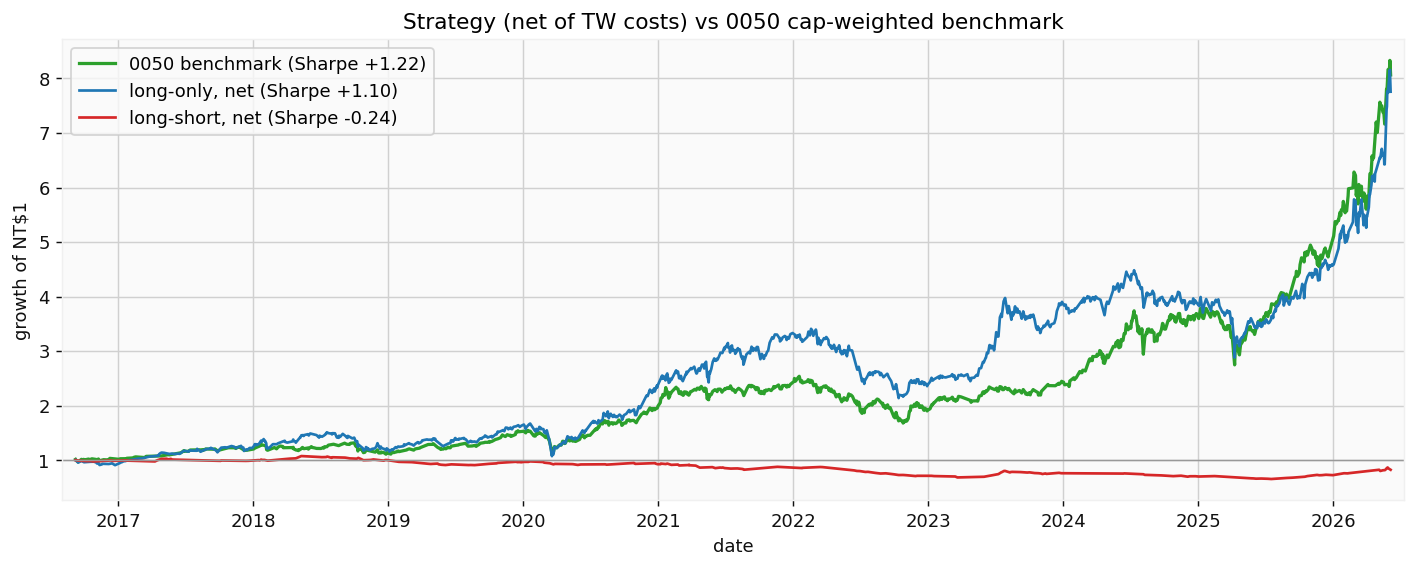

0050 benchmark: Sharpe +1.22 | annRet +24.2% | vol 19.8% | MDD -33.8%


In [30]:
# Benchmark: 0050.TW cap-weighted top-50 ETF (buy & hold), same OOS window.
bench = engine.equity_stats(engine.benchmark_returns(), window=res_ls["net_ret"].index)
fig_dir = config.REPORTS_DIR

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(bench["curve"].index, bench["curve"].values, color="C2", lw=1.8,
        label=f"0050 benchmark (Sharpe {bench['sharpe']:+.2f})")
ax.plot(res_lo["net_curve"].index, res_lo["net_curve"].values, color="C0", lw=1.5,
        label=f"long-only, net (Sharpe {res_lo['sharpe_net']:+.2f})")
ax.plot(res_ls["net_curve"].index, res_ls["net_curve"].values, color="C3", lw=1.5,
        label=f"long-short, net (Sharpe {res_ls['sharpe_net']:+.2f})")
ax.axhline(1.0, color="0.6", lw=0.8)
ax.set_title("Strategy (net of TW costs) vs 0050 cap-weighted benchmark")
ax.set_ylabel("growth of NT$1"); ax.set_xlabel("date"); ax.legend(loc="upper left"); ax.margins(x=0.01)
fig.tight_layout(); fig.savefig(fig_dir / "equity_vs_benchmark.png", dpi=130, bbox_inches="tight")
plt.close(fig)
display(Image(str(fig_dir / "equity_vs_benchmark.png")))
print(f"0050 benchmark: Sharpe {bench['sharpe']:+.2f} | annRet {bench['ann_return']:+.1%} "
      f"| vol {bench['ann_vol']:.1%} | MDD {bench['mdd']:+.1%}")

## 7 · Drift monitoring — `drift.run_monitoring`

The three-ring framework: **(1) performance** — rolling 60-day IC; **(2) input
drift** — PSI/KS per *raw* feature, early vs late (cross-sectional z-scoring hides
level drift, so we monitor the raw features); **(3) regime** — a realized-vol
percentile flag. The batch artifact is an Evidently report at `reports/drift.html`.

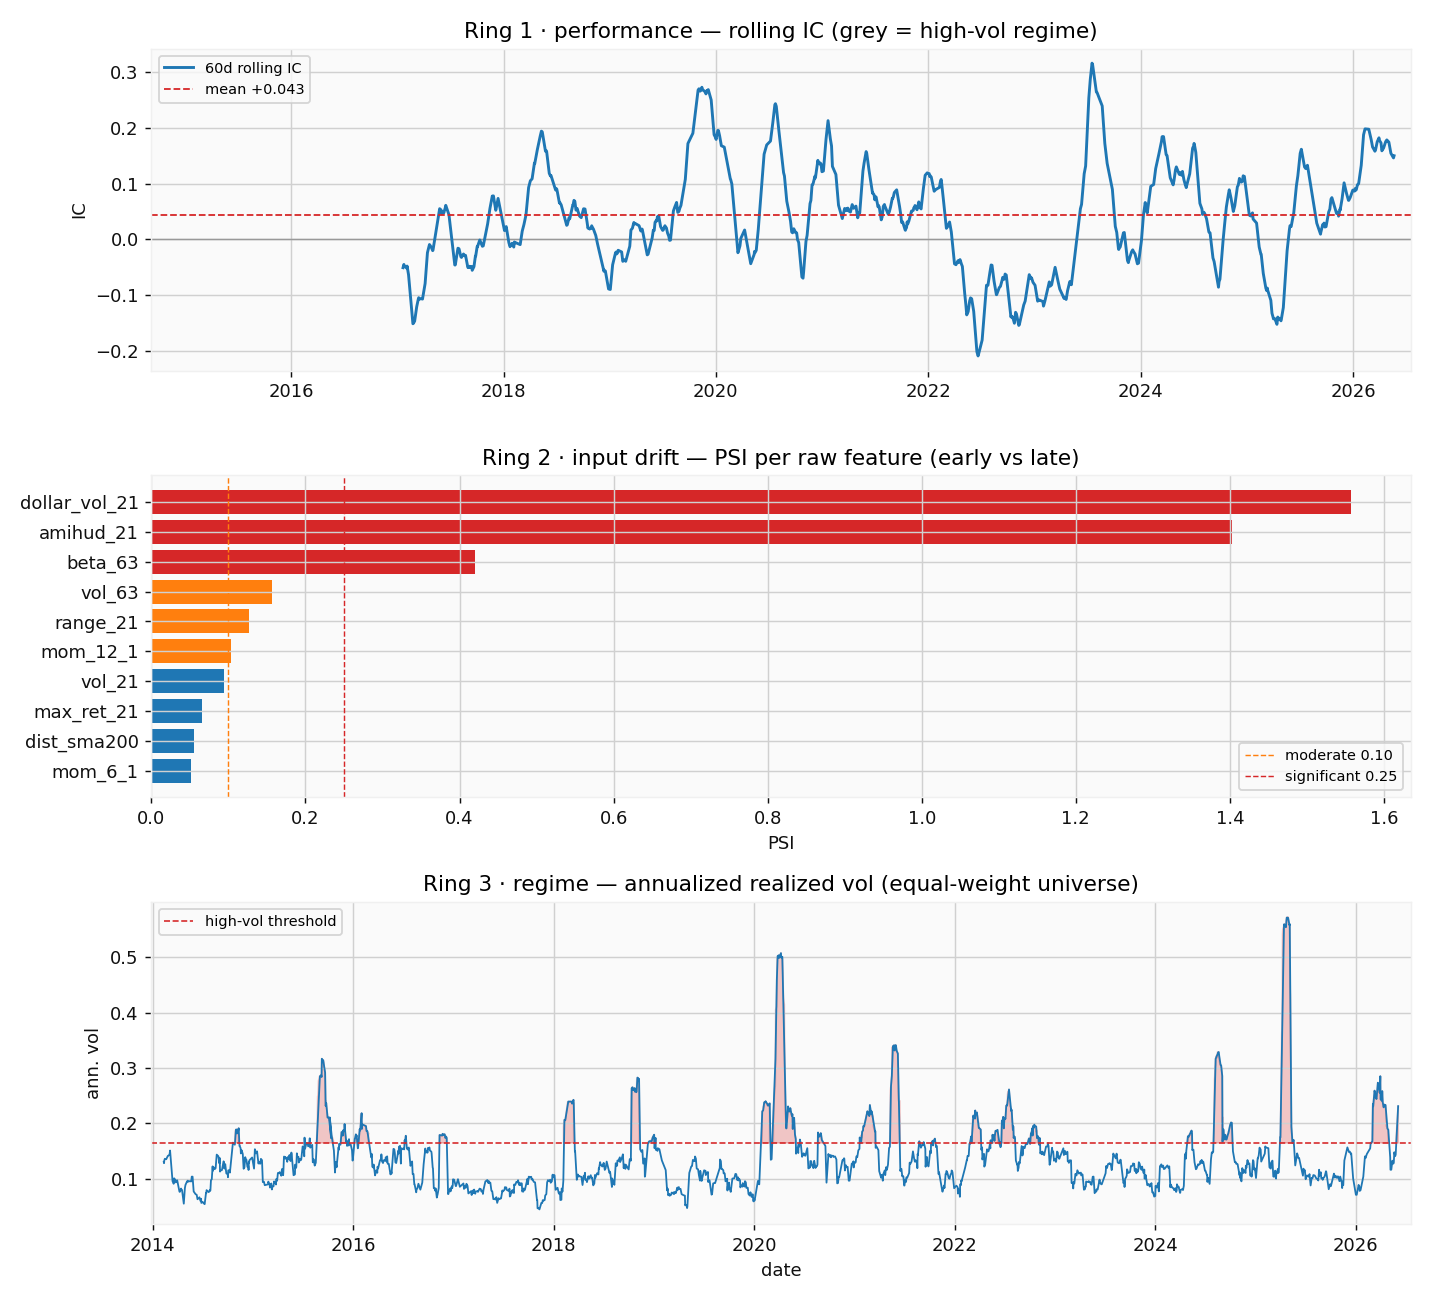

,feature,psi,ks_stat,ks_pvalue,drift
0,dollar_vol_21,1.556695,0.482156,0.000000e+00,significant
1,amihud_21,1.402450,0.456825,0.000000e+00,significant
2,beta_63,0.419888,0.279402,0.000000e+00,significant
3,vol_63,0.156070,0.148267,0.000000e+00,moderate
4,range_21,0.127119,0.137013,0.000000e+00,moderate
5,mom_12_1,0.103909,0.076671,4.581542e-107,moderate
6,vol_21,0.094592,0.110049,2.027965e-220,stable
7,max_ret_21,0.065040,0.097919,1.683976e-174,stable


In [31]:
raw = alpha.build_raw_features(prices)
mon = drift.run_monitoring(predictions=preds, raw_features=raw,
                           returns=rets, make_html=True)
display(Image(str(mon["monitoring_png"])))
mon["drift"].head(8)

## Results summary — the slide

One clean table of every headline number, assembled from the stage outputs above.

In [32]:
signal = pd.DataFrame({
    "metric": ["mean daily IC", "ICIR (overlap-adj)", "ICIR (naive √252)",
               "IC t-stat", "IC hit rate"],
    "value": [f"{ic_stats['mean_ic']:+.4f}", f"{ic_stats['icir_ann']:+.2f}",
              f"{ic_stats['icir_naive']:+.2f}", f"{ic_stats['ic_tstat']:+.2f}",
              f"{ic_stats['hit_rate']:.1%}"],
    "sanity band": ["0.01–0.04", "0.5–2.0", "(inflated)", "—", "—"],
})
display(signal)

def _row(name, r):
    return {"strategy": name, "Sharpe gross": round(r["sharpe_gross"], 2),
            "Sharpe net": round(r["sharpe_net"], 2), "ann ret": f"{r['ann_return']:+.1%}",
            "vol": f"{r['ann_vol']:.1%}", "max DD": f"{r['mdd']:+.1%}",
            "Calmar": round(r["calmar"], 2), "turnover/rebal": f"{r['avg_turnover']:.1%}",
            "hit": f"{r['hit_rate']:.1%}"}

bench_row = {"strategy": "0050 benchmark (buy&hold)", "Sharpe gross": "—",
             "Sharpe net": round(bench["sharpe"], 2), "ann ret": f"{bench['ann_return']:+.1%}",
             "vol": f"{bench['ann_vol']:.1%}", "max DD": f"{bench['mdd']:+.1%}",
             "Calmar": round(bench["calmar"], 2), "turnover/rebal": "0.0%", "hit": "—"}

backtest_tbl = pd.DataFrame([_row("long-short (ideal)", res_ls),
                             _row("long-only (real)", res_lo),
                             bench_row]).set_index("strategy")
display(backtest_tbl)

,metric,value,sanity band
0,mean daily IC,+0.0433,0.01–0.04
1,ICIR (overlap-adj),+1.03,0.5–2.0
2,ICIR (naive √252),+3.24,(inflated)
3,IC t-stat,+9.78,—
4,IC hit rate,58.4%,—


,Sharpe gross,Sharpe net,ann ret,vol,max DD,Calmar,turnover/rebal,hit
strategy,,,,,,,,
long-short (ideal),0.61,-0.24,-1.8%,7.6%,-40.0%,-0.04,88.3%,48.8%
long-only (real),1.38,1.10,+24.3%,22.0%,-37.3%,0.65,86.4%,55.5%
0050 benchmark (buy&hold),—,1.22,+24.2%,19.8%,-33.8%,0.72,0.0%,—


In [33]:
artifacts = sorted(p.name for p in config.REPORTS_DIR.glob("*") if p.suffix in {".png", ".html"})
print("Slide-ready artifacts in reports/:")
for a in artifacts:
    print("  •", a)

Slide-ready artifacts in reports/:
  • cv_fold_map.png
  • cv_overlap_strip.png
  • cv_purge_zoom.png
  • cv_twosided_vs_expanding.png
  • drift.html
  • equity_gross_net.png
  • equity_long_only.png
  • equity_vs_benchmark.png
  • monitoring.png
  • price_overview_2330.png
  • rolling_ic.png
  • strategy_compare.png


**Honest read.** A modest, real cross-sectional signal (mean IC ≈ 0.043, ICIR ≈ 1.0
overlap-adjusted). After the **real Taiwan cost stack** (0.1425%/side fee + 0.3% sell
tax), the dollar-neutral long-short's thin gross edge turns negative — the fix is a
longer hold / signal smoothing, *not* a fancier model. The long-only top-quintile
(net Sharpe ≈ 1.0) is competitive but still **does not beat the 0050 cap-weighted
benchmark (≈ 1.2)** after costs. Known limitations — survivorship bias, concentration,
short availability — are named in the README, not hidden.